# Lab 1 — Extracting Stock Data Using a Python Library

This notebook demonstrates how to extract stock data using the `yfinance` Python library. We retrieve historical share prices, stock metadata, and dividend information for **Apple (AAPL)** and **AMD (AMD)**.

## Table of Contents
1. [Setup & Imports](#setup)
2. [Extract Apple Stock Data](#apple)
   - Stock Info
   - Historical Share Price
   - Dividends
3. [Exercise — AMD Stock Data](#exercise)


In [11]:
# Install required libraries (run once)
!pip install yfinance matplotlib --quiet

In [12]:
import json
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## 1. Extract Apple Stock Data <a id='apple'></a>

We use the `yfinance.Ticker` object to access Apple's stock data via its ticker symbol `AAPL`.

In [13]:
apple = yf.Ticker("AAPL")

### Stock Info

The `info` attribute returns a dictionary of metadata about the stock, including country, sector, and market cap.

In [14]:
import json

with open('apple.json') as f:
    apple_info = json.load(f)

print("Country:", apple_info['country'])
print("Sector:", apple_info['sector'])
print("Market Cap:", apple_info['marketCap'])

Country: United States
Sector: Technology
Market Cap: 2901099675648


### Historical Share Price

Using `history(period='max')` retrieves the full available price history as a Pandas DataFrame, with columns for Open, High, Low, Close, Volume, and Stock Splits.

In [15]:
apple_share_price_data = apple.history(period="max")
apple_share_price_data.reset_index(inplace=True)
apple_share_price_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12 00:00:00-05:00,0.098297,0.098725,0.098297,0.098297,469033600,0.0,0.0
1,1980-12-15 00:00:00-05:00,0.093597,0.093597,0.093169,0.093169,175884800,0.0,0.0
2,1980-12-16 00:00:00-05:00,0.086758,0.086758,0.086331,0.086331,105728000,0.0,0.0
3,1980-12-17 00:00:00-05:00,0.088468,0.088895,0.088468,0.088468,86441600,0.0,0.0
4,1980-12-18 00:00:00-05:00,0.091033,0.091460,0.091033,0.091033,73449600,0.0,0.0


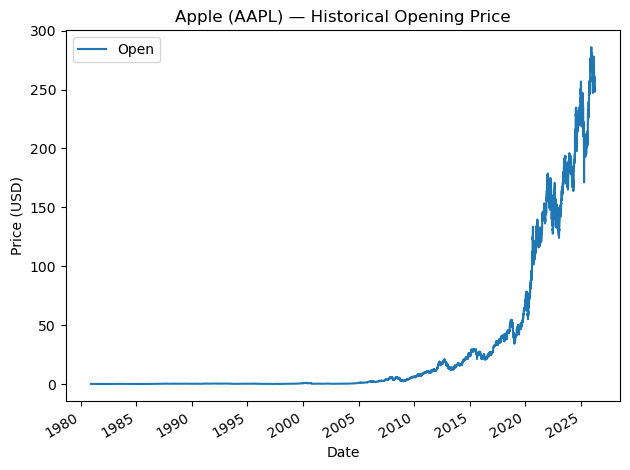

In [16]:
# Plot Apple opening price over time
apple_share_price_data.plot(x="Date", y="Open", title="Apple (AAPL) — Historical Opening Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

### Dividends

Dividends are periodic payments made to shareholders from company profits. The `dividends` attribute returns a time series of dividend amounts.

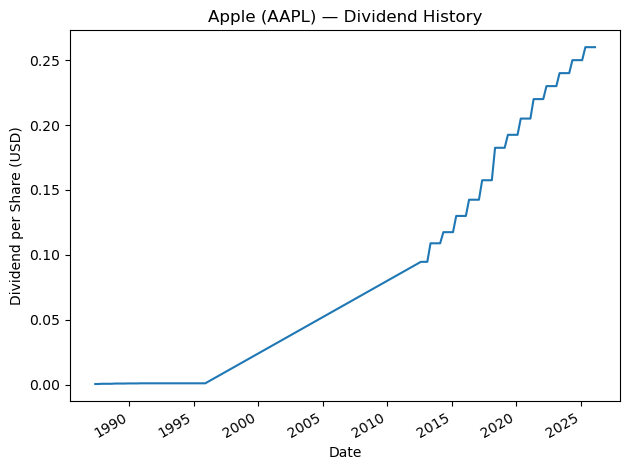

In [17]:
apple.dividends.plot(title="Apple (AAPL) — Dividend History")
plt.ylabel("Dividend per Share (USD)")
plt.tight_layout()
plt.show()

## 2. Exercise — AMD Stock Data <a id='exercise'></a>

We repeat the same extraction process for **Advanced Micro Devices (AMD)**.

In [18]:
amd = yf.Ticker("AMD")

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/data/amd.json'

with open('amd.json') as f:
    amd_info = json.load(f)

In [19]:
# Q1: Country
print("Country:", amd_info['country'])

# Q2: Sector
print("Sector:", amd_info['sector'])

Country: United States
Sector: Technology


In [20]:
# Q3: Volume traded on the first available trading day
amd_history = amd.history(period="max")
print("Volume on first trading day:", amd_history['Volume'].iloc[0])

Volume on first trading day: 219600
